<h2 style="color:blue; text-align:center;"> Practica 3</h2>

<h3> <b>Parte 1 -  Análisis de Robustez (Hu vs. Zernike) </b> </h3>

<h4> Prepocesamiento y Aumento de Datos: </h4>


In [1]:
# Carga del dataset 
import random, numpy as np
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = "all-images/" 
IMG_SIZE = 128  


In [2]:
# Clases de imágenes    
import os
def listar_clases(root):
    clases = [c for c in os.listdir(root) if os.path.isdir(os.path.join(root, c))]
    return sorted(clases)


class_dirs = listar_clases(DATA_ROOT)
class_dirs[:10], len(class_dirs)


(['circle', 'square', 'triangle'], 3)

In [3]:

from glob import glob
import pandas as pd

rows = []

for c in class_dirs:
    class_path = os.path.join(DATA_ROOT, c)
    label = c   

    files = glob(os.path.join(class_path, "**", "*.PNG"), recursive=True)

    for f in files:
        rows.append((f, label))

df = pd.DataFrame(rows, columns=["path", "label"])

df["label"].value_counts(), df.head()


(label
 square      129
 triangle    115
 circle      114
 Name: count, dtype: int64,
                             path   label
 0     all-images/circle/c3-1.PNG  circle
 1    all-images/circle/c1i-2.PNG  circle
 2  all-images/circle/c11ci-2.PNG  circle
 3    all-images/circle/c6n-2.PNG  circle
 4    all-images/circle/c6i-0.PNG  circle)

Lectura de la imagen

In [4]:
import cv2
def read_image(path, size=IMG_SIZE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    return img

def binarize(img):
    blur = cv2.GaussianBlur(img, (5,5), 0)

    _, th = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    kernel = np.ones((3,3), np.uint8)
    th = cv2.morphologyEx(th, cv2.MORPH_OPEN, kernel, iterations=1)
    th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel, iterations=1)

    return th



Funcion de ruido gaussiano tipo Gaussian y Salt & Pepper

In [5]:
NOISE_LEVELS = {
    "low":   {"gauss_sigma": 8,  "sp_prob": 0.01},
    "mid":   {"gauss_sigma": 18, "sp_prob": 0.03},
    "high":  {"gauss_sigma": 30, "sp_prob": 0.06},
}

def ruido_gaussiano(img, sigma):
    noise = np.random.normal(0, sigma, img.shape).astype(np.float32)
    out = img.astype(np.float32) + noise
    out = np.clip(out, 0, 255).astype(np.uint8)
    return out

def ruido_salt_pepper(img, prob):
    out = img.copy()
    rnd = np.random.rand(*img.shape)
    out[rnd < (prob/2)] = 0
    out[rnd > 1 - (prob/2)] = 255
    return out


Funcion para rotacion aleatoria de la imagen

In [6]:
def random_rotate(img):
    angle = random.uniform(0, 360)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    rot = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderValue=0)
    return rot


<h4> Extracción de Características: </h4>

Hu Moments

In [7]:
def hu_moments_log(binary_img):
    # binary_img: 0/255, con figura en blanco
    m = cv2.moments(binary_img)
    hu = cv2.HuMoments(m).flatten()
    eps = 1e-30
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + eps)
    return hu_log.astype(np.float32)


Zernike Moments

In [8]:
import mahotas
def zernike_moments(binary_img, degree=8):
    img01 = (binary_img > 0).astype(np.uint8)
    radius = min(img01.shape)//2
    return mahotas.features.zernike_moments(img01, radius, degree=degree).astype(np.float32)


<h4> Evaluación de Clasificación: </h4>

In [9]:
from tqdm import tqdm
def build_features(df_subset, descriptor="hu", noise_type=None, noise_level=None, rotate=True):
    X, y = [], []
    for path, label in tqdm(df_subset[["path","label"]].values, total=len(df_subset)):
        img = read_image(path)
        if rotate:
            img = random_rotate(img)

        if noise_type and noise_level:
            params = NOISE_LEVELS[noise_level]
            if noise_type == "gaussian":
                img = ruido_gaussiano(img, params["gauss_sigma"])
            elif noise_type == "sp":
                img = ruido_salt_pepper(img, params["sp_prob"])

        b = binarize(img)
        
        if descriptor == "hu":
            feat = hu_moments_log(b)
        elif descriptor == "zernike":
            feat = zernike_moments(b, degree=8)
        else:
            raise ValueError("descriptor debe ser 'hu' o 'zernike'")

        X.append(feat)
        y.append(label)

    X = np.vstack(X)
    y = np.array(y)
    return X, y


In [10]:
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    random_state=SEED,
    stratify=df["label"]
)

train_df["label"].value_counts(), test_df["label"].value_counts()


(label
 square      97
 triangle    86
 circle      85
 Name: count, dtype: int64,
 label
 square      32
 triangle    29
 circle      29
 Name: count, dtype: int64)

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

def train_and_eval(Xtr, ytr, Xte, yte, model_name="svm"):
    if model_name == "svm":
        model = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale"))
    elif model_name == "knn":
        model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))
    else:
        raise ValueError("model_name debe ser 'svm' o 'knn'")

    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    acc = accuracy_score(yte, pred)
    return model, pred, acc



=== HU | gaussian | low ===


100%|██████████| 90/90 [00:00<00:00, 685.38it/s]


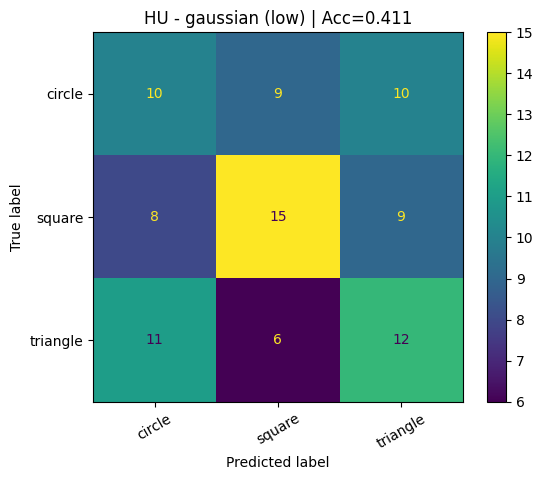

              precision    recall  f1-score   support

      circle       0.34      0.34      0.34        29
      square       0.50      0.47      0.48        32
    triangle       0.39      0.41      0.40        29

    accuracy                           0.41        90
   macro avg       0.41      0.41      0.41        90
weighted avg       0.41      0.41      0.41        90


=== HU | gaussian | mid ===


100%|██████████| 90/90 [00:00<00:00, 697.68it/s]


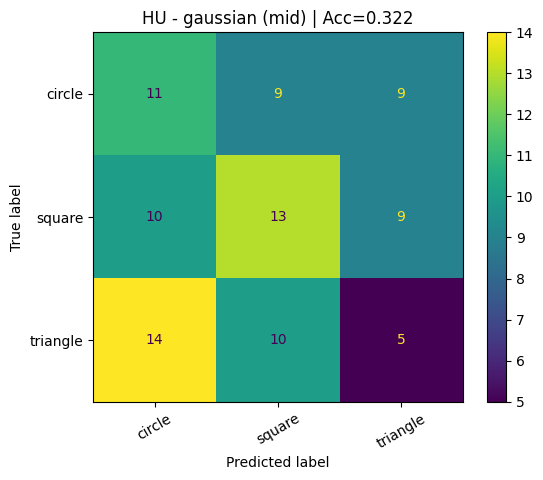

              precision    recall  f1-score   support

      circle       0.31      0.38      0.34        29
      square       0.41      0.41      0.41        32
    triangle       0.22      0.17      0.19        29

    accuracy                           0.32        90
   macro avg       0.31      0.32      0.31        90
weighted avg       0.32      0.32      0.32        90


=== HU | gaussian | high ===


100%|██████████| 90/90 [00:00<00:00, 673.77it/s]


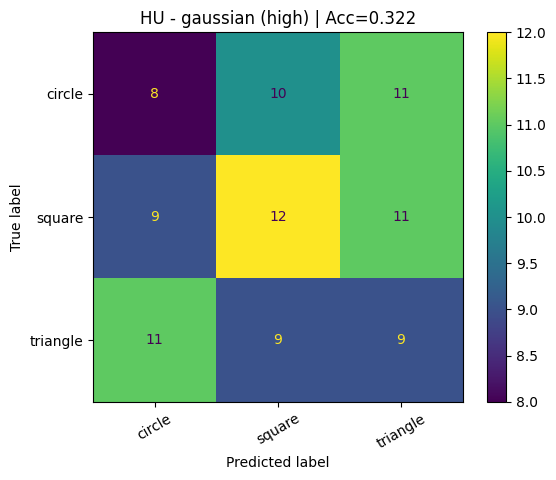

              precision    recall  f1-score   support

      circle       0.29      0.28      0.28        29
      square       0.39      0.38      0.38        32
    triangle       0.29      0.31      0.30        29

    accuracy                           0.32        90
   macro avg       0.32      0.32      0.32        90
weighted avg       0.32      0.32      0.32        90


=== HU | sp | low ===


100%|██████████| 90/90 [00:00<00:00, 847.23it/s]


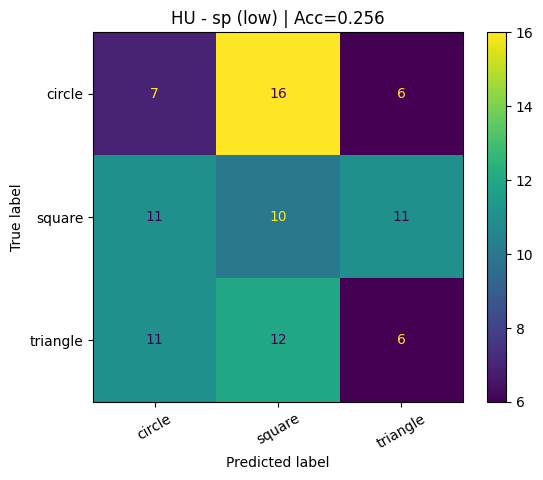

              precision    recall  f1-score   support

      circle       0.24      0.24      0.24        29
      square       0.26      0.31      0.29        32
    triangle       0.26      0.21      0.23        29

    accuracy                           0.26        90
   macro avg       0.26      0.25      0.25        90
weighted avg       0.26      0.26      0.25        90


=== HU | sp | mid ===


100%|██████████| 90/90 [00:00<00:00, 850.13it/s]


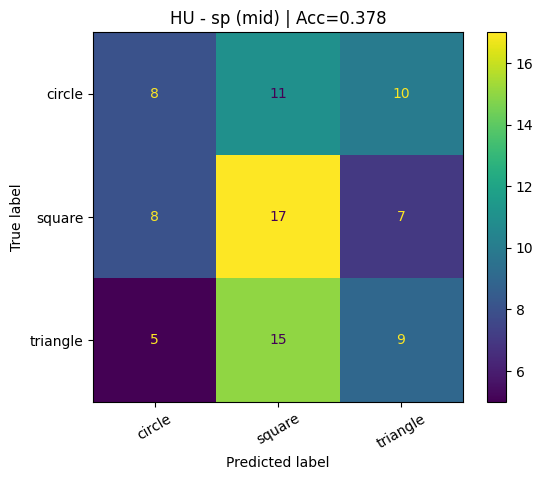

              precision    recall  f1-score   support

      circle       0.38      0.28      0.32        29
      square       0.40      0.53      0.45        32
    triangle       0.35      0.31      0.33        29

    accuracy                           0.38        90
   macro avg       0.37      0.37      0.37        90
weighted avg       0.37      0.38      0.37        90


=== HU | sp | high ===


100%|██████████| 90/90 [00:00<00:00, 857.33it/s]


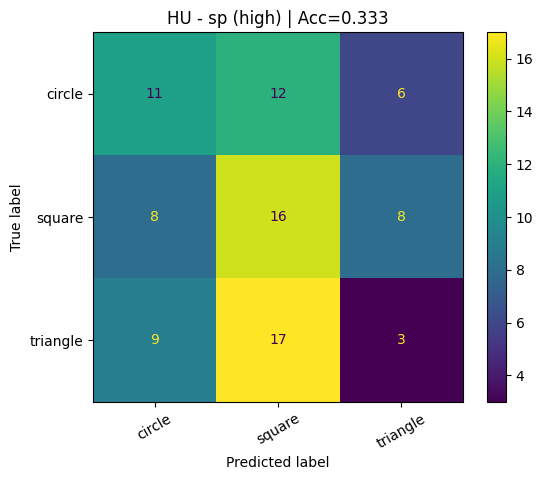

              precision    recall  f1-score   support

      circle       0.39      0.38      0.39        29
      square       0.36      0.50      0.42        32
    triangle       0.18      0.10      0.13        29

    accuracy                           0.33        90
   macro avg       0.31      0.33      0.31        90
weighted avg       0.31      0.33      0.31        90


=== ZERNIKE | gaussian | low ===


100%|██████████| 90/90 [00:01<00:00, 87.90it/s]


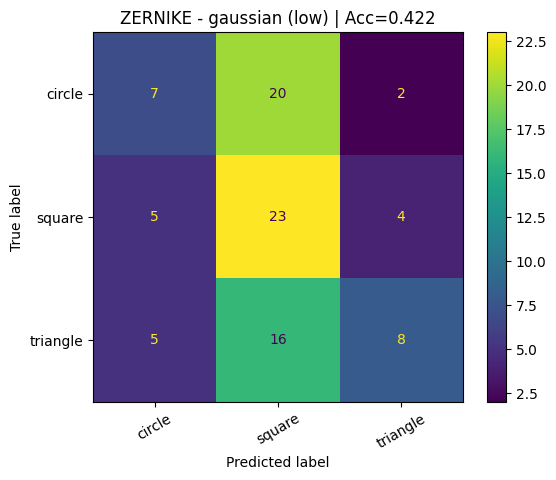

              precision    recall  f1-score   support

      circle       0.41      0.24      0.30        29
      square       0.39      0.72      0.51        32
    triangle       0.57      0.28      0.37        29

    accuracy                           0.42        90
   macro avg       0.46      0.41      0.39        90
weighted avg       0.46      0.42      0.40        90


=== ZERNIKE | gaussian | mid ===


100%|██████████| 90/90 [00:01<00:00, 86.15it/s]


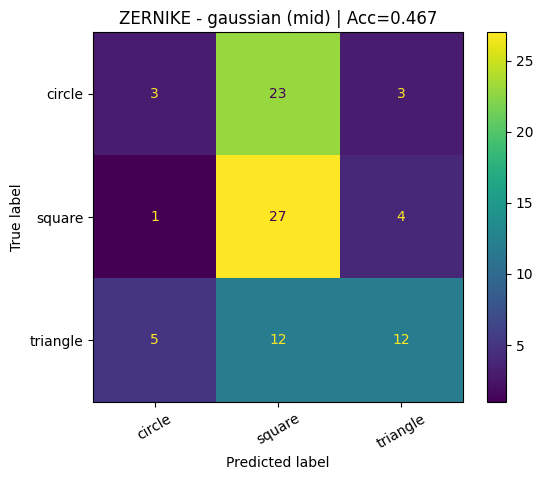

              precision    recall  f1-score   support

      circle       0.33      0.10      0.16        29
      square       0.44      0.84      0.57        32
    triangle       0.63      0.41      0.50        29

    accuracy                           0.47        90
   macro avg       0.47      0.45      0.41        90
weighted avg       0.47      0.47      0.42        90


=== ZERNIKE | gaussian | high ===


100%|██████████| 90/90 [00:01<00:00, 88.27it/s]


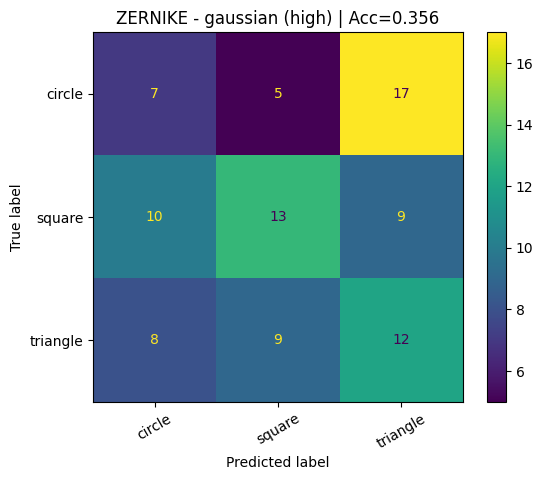

              precision    recall  f1-score   support

      circle       0.28      0.24      0.26        29
      square       0.48      0.41      0.44        32
    triangle       0.32      0.41      0.36        29

    accuracy                           0.36        90
   macro avg       0.36      0.35      0.35        90
weighted avg       0.36      0.36      0.36        90


=== ZERNIKE | sp | low ===


100%|██████████| 90/90 [00:00<00:00, 90.86it/s]


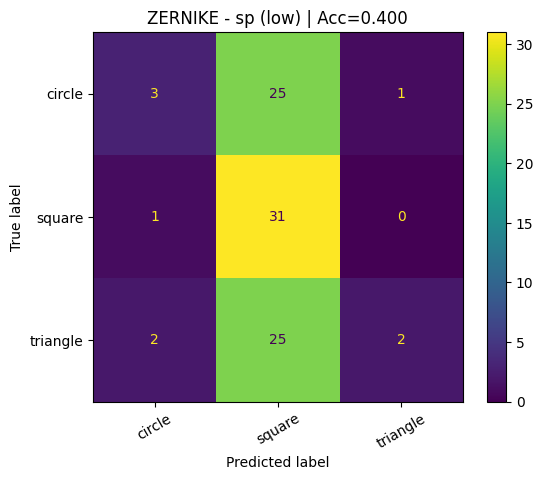

              precision    recall  f1-score   support

      circle       0.50      0.10      0.17        29
      square       0.38      0.97      0.55        32
    triangle       0.67      0.07      0.12        29

    accuracy                           0.40        90
   macro avg       0.52      0.38      0.28        90
weighted avg       0.51      0.40      0.29        90


=== ZERNIKE | sp | mid ===


100%|██████████| 90/90 [00:01<00:00, 88.37it/s]


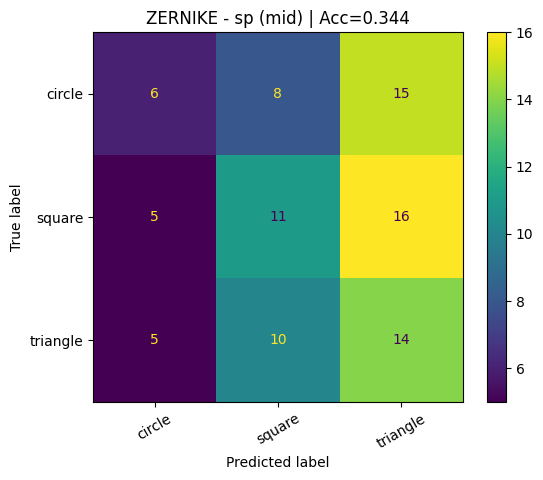

              precision    recall  f1-score   support

      circle       0.38      0.21      0.27        29
      square       0.38      0.34      0.36        32
    triangle       0.31      0.48      0.38        29

    accuracy                           0.34        90
   macro avg       0.36      0.34      0.34        90
weighted avg       0.36      0.34      0.34        90


=== ZERNIKE | sp | high ===


100%|██████████| 90/90 [00:01<00:00, 88.63it/s]


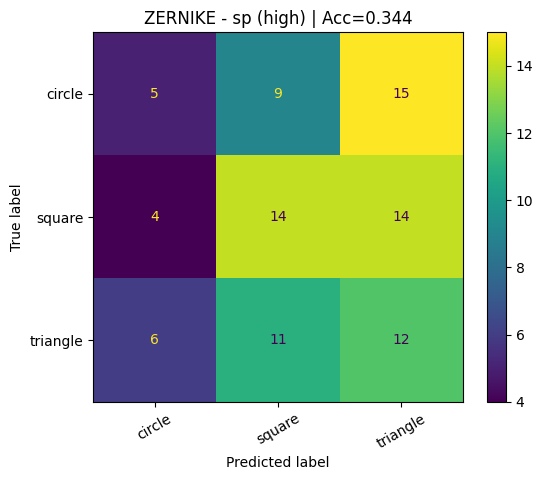

              precision    recall  f1-score   support

      circle       0.33      0.17      0.23        29
      square       0.41      0.44      0.42        32
    triangle       0.29      0.41      0.34        29

    accuracy                           0.34        90
   macro avg       0.35      0.34      0.33        90
weighted avg       0.35      0.34      0.33        90



In [12]:
import matplotlib.pyplot as plt

labels_sorted = sorted(df["label"].unique())

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
    disp.plot(values_format="d")
    plt.title(title)
    plt.xticks(rotation=30)
    plt.show()

results = []

for descriptor in ["hu", "zernike"]:
    for noise_type in ["gaussian", "sp"]:
        for level in ["low","mid","high"]:
            print(f"\n=== {descriptor.upper()} | {noise_type} | {level} ===")

            Xtr, ytr = build_features(train_df, descriptor=descriptor,
                                     noise_type=noise_type, noise_level=level, rotate=True)
            Xte, yte = build_features(test_df, descriptor=descriptor,
                                     noise_type=noise_type, noise_level=level, rotate=True)

            _, pred, acc = train_and_eval(Xtr, ytr, Xte, yte, model_name="svm")
            results.append((descriptor, noise_type, level, acc))

            plot_cm(yte, pred, title=f"{descriptor.upper()} - {noise_type} ({level}) | Acc={acc:.3f}")
            print(classification_report(yte, pred))


In [13]:
res_df = pd.DataFrame(results, columns=["descriptor","noise_type","level","accuracy"])
pivot = res_df.pivot_table(index=["noise_type","level"], columns="descriptor", values="accuracy")
pivot


descriptor              hu   zernike
noise_type level                    
gaussian   high   0.322222  0.355556
           low    0.411111  0.422222
           mid    0.322222  0.466667
sp         high   0.333333  0.344444
           low    0.255556  0.400000
           mid    0.377778  0.344444

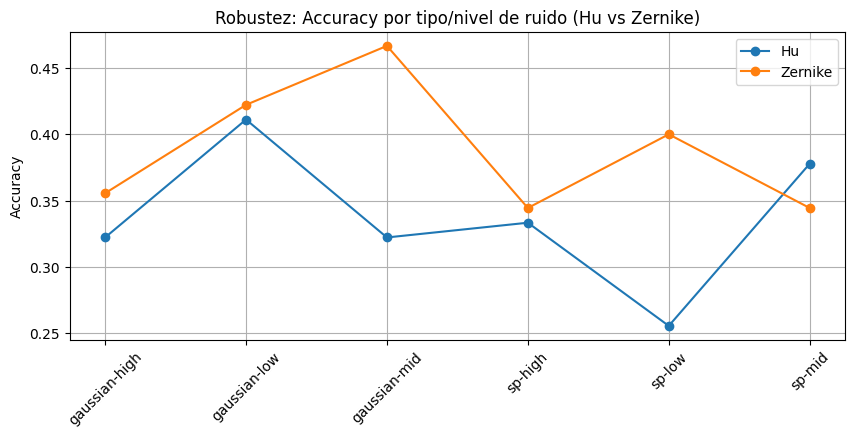

In [14]:
pivot_plot = pivot.reset_index()
pivot_plot["cond"] = pivot_plot["noise_type"] + "-" + pivot_plot["level"]

plt.figure(figsize=(10,4))
plt.plot(pivot_plot["cond"], pivot_plot["hu"], marker="o", label="Hu")
plt.plot(pivot_plot["cond"], pivot_plot["zernike"], marker="o", label="Zernike")
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.title("Robustez: Accuracy por tipo/nivel de ruido (Hu vs Zernike)")
plt.legend()
plt.grid(True)
plt.show()
